In [173]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.ndimage import maximum_filter1d
import openpyxl
from agcounts_filter import convert_AC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

Récupération des X vitesses angulaires

In [174]:
folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)

# Initialisation des listes contenant les données des capteurs
X_gyro_dom = []
Y_gyro_dom = []
Z_gyro_dom = []
X_gyro_non_dom = []
Y_gyro_non_dom = []
Z_gyro_non_dom = []

for file in folder: 
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    if extension == ".csv":
        # Récupération des données des capteurs
        data_file = pd.read_csv(folder_path + "/" + file, header = 5, names = ["Timestamp","Gyro X","Gyro Y","Gyro Z","Accelerometer X","Accelerometer Y","Accelerometer Z","Event","Quat W","Quat X","Quat Y","Quat Z","None"])    
        
        if file[-11:-4] == "non_dom":
            X_gyro_non_dom.extend(data_file["Gyro X"].values.tolist()) 
            Y_gyro_non_dom.extend(data_file["Gyro Y"].values.tolist()) 
            Z_gyro_non_dom.extend(data_file["Gyro Z"].values.tolist())
        
        elif file[-7:-4] == "dom":
            X_gyro_dom.extend(data_file["Gyro X"].values.tolist()) #.append(data_file["Gyro X"][data])
            Y_gyro_dom.extend(data_file["Gyro Y"].values.tolist()) #.append(data_file["Gyro Y"][data])
            Z_gyro_dom.extend(data_file["Gyro Z"].values.tolist()) #.append(data_file["Gyro Z"][data])
        

print(len(X_gyro_dom))


On est dans le fichier : Autres
On est dans le fichier : Data_10_dom.csv
On est dans le fichier : Data_10_non_dom.csv
On est dans le fichier : Data_10_X.xlsx
On est dans le fichier : Data_11_dom.csv
On est dans le fichier : Data_11_non_dom.csv
On est dans le fichier : Data_11_X.xlsx
On est dans le fichier : Data_16_dom.csv
On est dans le fichier : Data_16_non_dom.csv
On est dans le fichier : Data_16_X.xlsx
On est dans le fichier : Data_2_dom.csv
On est dans le fichier : Data_2_non_dom.csv
On est dans le fichier : Data_2_X.xlsx
On est dans le fichier : Data_3_dom.csv
On est dans le fichier : Data_3_non_dom.csv
On est dans le fichier : Data_3_X.xlsx
On est dans le fichier : Data_4_dom.csv
On est dans le fichier : Data_4_non_dom.csv
On est dans le fichier : Data_4_X.xlsx
On est dans le fichier : Data_5_dom.csv
On est dans le fichier : Data_5_non_dom.csv
On est dans le fichier : Data_5_X.xlsx
On est dans le fichier : Data_6_dom.csv
On est dans le fichier : Data_6_non_dom.csv
On est dans le

In [175]:
#Filtre passe bas frequence 17Hz "The signal from the sensors were amplified and low-pass filtered (cutoff frequency:17 Hz) to remove any electronic noise and artifacts."




Définition du seuil adaptatif

Seuil adaptatif : 46.88 °/s


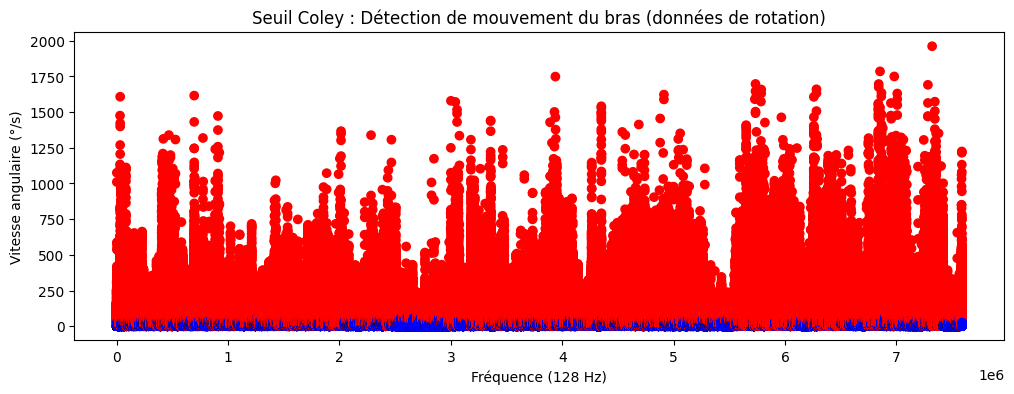

In [ ]:
# ------------------------- Norme des mouvements ---------------------------
acc_data = []
acc_data_1s = []
for i in range(len(X_gyro_non_dom)):#for i in range(0,len(X_gyro_dom), 128):
    coordonnes = np.array([X_gyro_non_dom[i], Y_gyro_non_dom[i], Z_gyro_non_dom[i]])
    """for j in range(1, 128):
        coordonnes = np.array([X_gyro_dom[i], Y_gyro_dom[i], Z_gyro_dom[i]])
        norme_1s = np.linalg.norm(coordonnes)
        acc_data_1s.append(norme_1s)"""
    norme = np.linalg.norm(coordonnes)
    acc_data.append(norme)


#-------------------------- Paramètres --------------------------
sampling_rate = 128 
merge_window = int(1 * sampling_rate)  # 1 seconde
gap_threshold = int(0.5 * sampling_rate)  # 0.5 seconde
min_duration = int(1.5 * sampling_rate)  # 1.5 seconde

#-------------------------- Extraire les 3 axes gyroscopiques --------------------------
gyro_x = X_gyro_non_dom
gyro_y = Y_gyro_non_dom
gyro_z = Z_gyro_non_dom

#-------------------------- Détection des pics > 10°/s sur chaque axe --------------------------
mask_x = np.abs(np.array(gyro_x)) > 10
mask_y = np.abs(np.array(gyro_y)) > 10
mask_z = np.abs(np.array(gyro_z)) > 10

detected_x = np.abs(np.array(gyro_x)[mask_x])
detected_y = np.abs(np.array(gyro_y)[mask_y])
detected_z = np.abs(np.array(gyro_z)[mask_z])

#-------------------------- Moyenne des pics par axe --------------------------
    
mean_x = detected_x.mean() if len(detected_x) > 0 else np.inf
mean_y = detected_y.mean() if len(detected_y) > 0 else np.inf
mean_z = detected_z.mean() if len(detected_z) > 0 else np.inf

#-------------------------- Seuil adaptatif = min des moyennes --------------------------
adaptive_threshold = min(mean_x, mean_y, mean_z)
print(f"Seuil adaptatif : {adaptive_threshold:.2f} °/s")

#-------------------------- Détection brute : un mouvement si un axe dépasse le seuil --------------------------
   
movement_raw = (
    (np.abs(gyro_x) > adaptive_threshold) |
    (np.abs(gyro_y) > adaptive_threshold) |
    (np.abs(gyro_z) > adaptive_threshold)
).astype(int)


#-------------------------- Filtre max mobile (fusionner les mouvements séparés de < 0.5s) --------------------------
movement_merged = maximum_filter1d(movement_raw, size = merge_window)

#-------------------------- Filtre médian mobile (supprimer les mouvements < 1.5s) --------------------------
movement_prediction = medfilt(movement_merged, kernel_size = min_duration | 1)  # kernel must be odd

# 8. Visualisation
color_map = {0: 'blue', 1: 'red'}
# Convertir les labels en couleurs
colors = [color_map[label] for label in movement_prediction]

plt.figure(figsize=(12, 4))
#plt.plot(np.linalg.norm(movement_prediction, axis=1), label="Norme Gyro") # calcul de la norme du mouvement final
plt.scatter(range(len(acc_data)), acc_data, c=colors)#plt.plot(movement_prediction * adaptive_threshold, label="Mouvement détecté", color='orange')
#plt.axhline(adaptive_threshold, color='r', linestyle='--', label="Seuil adaptatif")
#plt.legend()
plt.title("Seuil Coley : Détection de mouvement du bras (données de rotation)")
plt.xlabel("Fréquence (128 Hz)")
plt.ylabel("Vitesse angulaire (°/s)")
#plt.tight_layout()
plt.show()


Récupération des données d'accélération et de leur annotations (vérité)

In [177]:
# LES X ET Y SONT SYNCHRONISE JUSTE LES Y NE CORRESPONDENT PAS DIRRECTEMENT AUX SECONDES DU EXCEL : CE SONT (LES SECONDES DU EXCEL)-(LE TEMPS DE DEPART)
# POUR LE FICHIER DATA 10 LES ANNOTATIONS SONT DECALEES DE 7 SEC

folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)

#//////////////////////////////AJOUTER UNE LISTE QUI DIT DOM ET NON DOM POUR CHAQUE FICHIER (la les Y sont bien classés mais forcément les X)
#lst_indic_dom = ["LW","LW","LW"]

# Initialisation des listes contenant les données des capteurs
X_non_dom = []
X_dom = []
idx_X_non_dom = 0
idx_X_dom = 0
idx_Y_dom = 0
idx_Y_non_dom = 0

# Initialisation des listes contenant les annotations vidéos
Y_non_dom = [] 
Y_dom = []


#Parcourir les fichiers CSV
for file in folder: #[0:7]
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None

    """********************************************************************** 1. Lecture des fichiers csv ******************************************************************************"""
    if extension == ".csv":

        # Visualisation des données des capteurs
        data_file = pd.read_csv(folder_path + "/" + file, header = 5, names = ["Timestamp","Gyro X","Gyro Y","Gyro Z","Accelerometer X","Accelerometer Y","Accelerometer Z","Event","Quat W","Quat X","Quat Y","Quat Z","None"])    

        # Conversion en AC 
        dom_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-11:-4] == "non_dom":
            list_dom_AC = dom_AC["AC"].tolist() # Conversion du type pd.serie en type list
            for ac in list_dom_AC :
                X_non_dom.append(ac)

        elif file[-7:-4] == "dom":
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC:
                X_dom.append(ac)

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        # Initialisation des décalages : sert pour éviter le décalage du aux arrondis des annotations 
        decalage_dom = 0
        decalage_non_dom = 0

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de Y ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_LW" :
                previous_row_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_RW" :
                previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True

            """****************************************************** Récupération du contenu de Y ****************************************"""

            if label.value[0:2] == "LW" and allow_start_dom:

                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_dom.append(None) #.append("décalage annotations")
                    
                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))) 
                for nb_sec in range(nb_repetitions): 
                    if X_dom and (len(Y_dom) == len(X_dom)) :
                        break
                    if label.value[3:13] == "sédentaire" :
                        # Y_dom[idx_Y_dom].append("non mouvement")
                        Y_dom.append("non mouvement")
                    elif label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        #Y_dom[idx_Y_dom].append("mouvement")
                        Y_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        #Y_dom[idx_Y_dom].append("non noté") #.append(None) 
                        Y_dom.append(None) #("non noté")


                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_dom = label.row


            elif label.value[0:2] == "RW" and allow_start_non_dom:
                
                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_non_dom.append(None) #.append("décalage annotations")

                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                for nb_sec in range(nb_repetitions): 
                    if X_non_dom and (len(Y_non_dom) == len(X_non_dom)): 
                        break
                    if label.value[3:13] == "sédentaire" :
                        Y_non_dom.append("non mouvement")
                    elif label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_non_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom.append(None)

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_non_dom = label.row
        
        # CROPER X A LA LONGUEUR DE Y 
        X_dom = X_dom[:len(Y_dom)]
        X_non_dom = X_non_dom[:len(Y_non_dom)]
        Y_dom = Y_dom[:len(X_dom)]
        Y_non_dom = Y_non_dom[:len(X_non_dom)]

        print(f"len X_dom {len(X_dom)}")
        print(f"Y_dom {Y_dom[608 : 615]}")




On est dans le fichier : Autres
On est dans le fichier : Data_10_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_10_non_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_10_X.xlsx
len X_dom 6793
Y_dom ['mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement']
On est dans le fichier : Data_11_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_11_non_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_11_X.xlsx
len X_dom 10422
Y_dom ['mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement']
On est dans le fichier : Data_16_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_16_non_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_16_X.xlsx
len X_dom 11847
Y_dom ['mouvement', 'mouvement', 'mouvement', '

In [197]:
# Laisser X_dom et faire tous les fichiers puis modifier X_non_dom et modifier dans le 2 cadre pour faire coley sur les non_dom, et refaire les fichiers
X_studied = X_dom
Y_studied = Y_dom

Modification de la fréquence des annotations prédites à 128 Hz pour comparer à la vérité (1 Hz)

In [198]:
def downsample_to_1Hz(binary_array, sampling_rate=128):
    n_seconds = len(binary_array) // sampling_rate
    binary_array = binary_array[:n_seconds * sampling_rate]  # tronquer pour être multiple de 128
    reshaped = binary_array.reshape(n_seconds, sampling_rate) # Majorité : si au moins 64 échantillons sont actifs, on considère la seconde comme mouvement
    return (reshaped.sum(axis=1) >= (sampling_rate // 2)).astype(int)

predicted_1Hz = downsample_to_1Hz(movement_prediction)

# Coupure des annotations prédictive à la longueur des données d'accélération (les données de mouvement ne sont pas toutes annotées)
predicted_1Hz = predicted_1Hz[:len(X_studied)]


Affichage comparaison annotations prédites et vérites (sans nettoyage des données = avec données None)

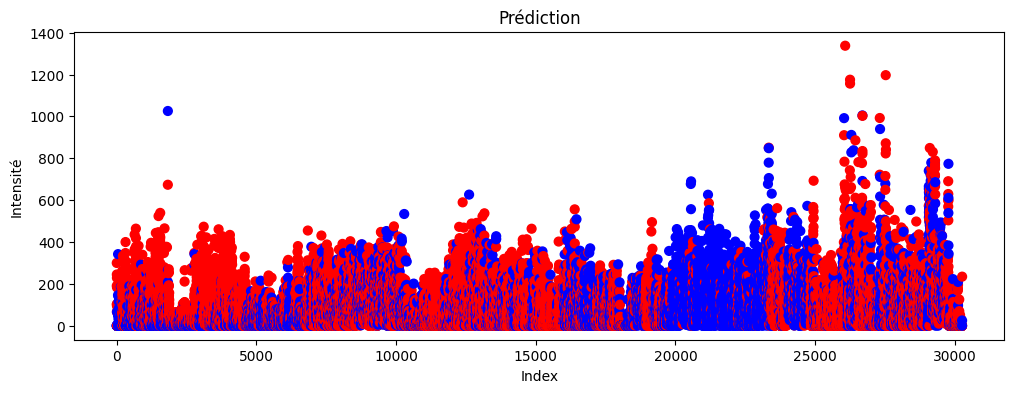

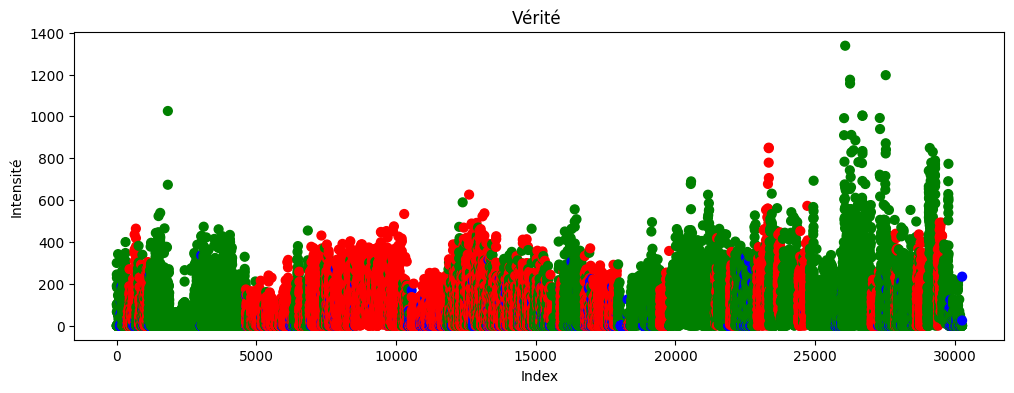

In [199]:
# Convertir les labels en couleurs
color_map = {0: 'blue', 1: 'red'}
colors = [color_map[label] for label in predicted_1Hz]

plt.figure(figsize=(12, 4))
plt.scatter(range(len(X_studied)), X_studied, c=colors, s=40) #plt.scatter(range(len(X_clean[0:400])), X_clean[0:400], c=colors, s=40)
plt.title("Prédiction") 
plt.xlabel("Index")
plt.ylabel("Intensité")
plt.show()

true_color_map = {'non mouvement': 'blue', 'mouvement': 'red', None: 'green'}
# Convertir les labels en couleurs
true_colors = [true_color_map[label] for label in Y_studied]

plt.figure(figsize=(12, 4))
plt.scatter(range(len(X_studied)), X_studied, c=true_colors, s=40) #plt.scatter(range(len(X_clean[0:400])), X_clean[0:400], c=colors, s=40)
plt.title("Vérité ") 
plt.xlabel("Index")
plt.ylabel("Intensité")
plt.show()

Affichage comparaison annotations prédites et vérité (données nettoyées)

In [200]:
# Convertir en array pour faciliter le filtrage
X_array = np.array(X_studied)
Y_array = np.array(Y_studied)

# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_None = Y_array != None
# Appliquer le masque aux données d'accelération
X_clean = X_array[mask_None]
Y_clean = Y_array[mask_None]
# Appliquer le masqie aux annotations prédites (rotations)
predicted_1Hz_clean = predicted_1Hz[mask_None]



Préparation des données

In [ ]:
#Equilibrer les données : autant de mouvement que de non mouvement, et dans le meme ordre que X_array et Y_array
# Compter les "non mouvement"
n_non_mvt = np.sum(Y_clean == 'non mouvement')
n_mvt = np.sum(Y_clean == 'mouvement')
# Sélectionner les indices dans l’ordre original
indices_mvt = np.where(Y_clean == 'mouvement')[0]
indices_non_mvt = np.where(Y_clean == 'non mouvement')[0]
# Si plus de mouvement
if n_non_mvt < n_mvt:
    # Garder les premiers `mouvement` rencontrés dans l'ordre
    indices_mvt_crop = indices_mvt[:n_non_mvt]
    # Fusionner les indices en gardant l’ordre du tableau initial
    indices_final = sorted(np.concatenate((indices_non_mvt, indices_mvt_crop)))
# Si plus de non mouvement
elif n_mvt < n_non_mvt :
    # Garder les premiers `non mouvement` rencontrés dans l'ordre
    indices_non_mvt_crop = indices_non_mvt[:n_mvt]
    # Fusionner les indices en gardant l’ordre du tableau initial
    indices_final = sorted(np.concatenate((indices_mvt, indices_non_mvt_crop)))

# Réorganise X et Y
X_balanced = X_clean[indices_final]
Y_balanced = Y_clean[indices_final]
predicted_1Hz_clean_balanced = predicted_1Hz_clean[indices_final]
# Aplatir les données (mettre au bon format pour les modèles)
X_flat = np.vstack(X_balanced)  # (n_total_samples, n_features)
Y_flat = np.hstack(Y_balanced)  # (n_total_samples,)

print(len(X_flat))
print(len(Y_flat))
# Convertir les 1 et 0 en mouvement et non mouvement
predicted_1Hz_clean_balanced_str = np.where(predicted_1Hz_clean_balanced == 1, "mouvement", "non mouvement")

3050
3050


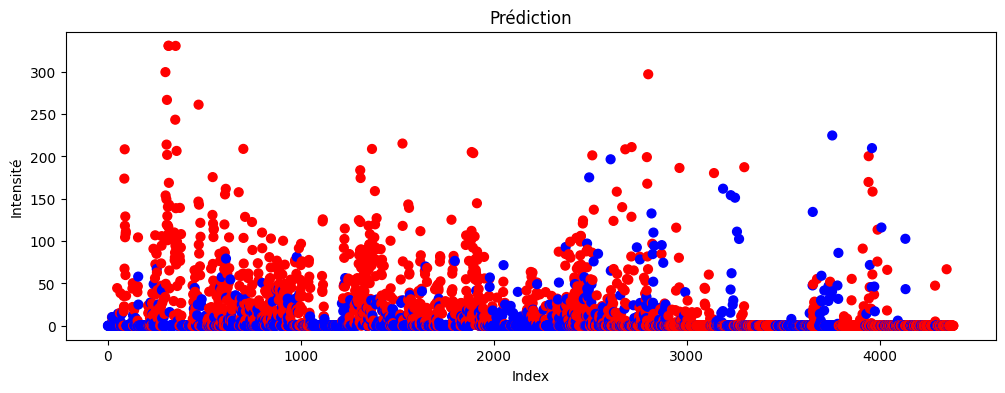

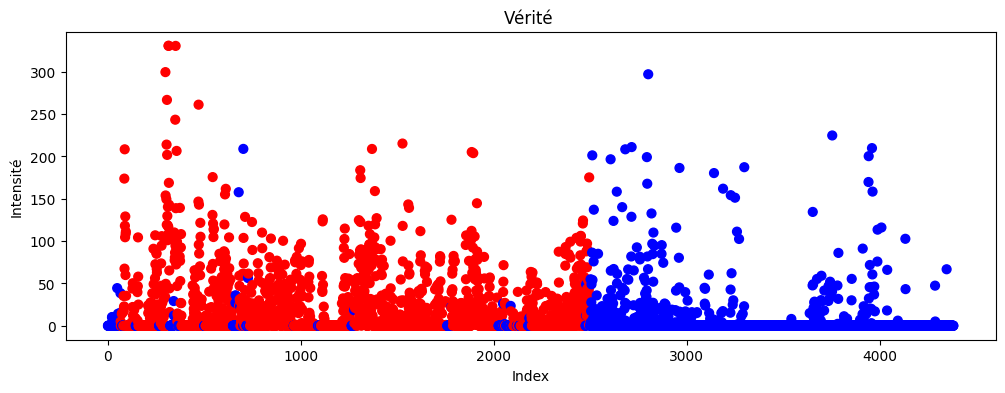

In [183]:
# Convertir les labels en couleurs
color_map = {'non mouvement': 'blue', 'mouvement': 'red'}
colors = [color_map[label] for label in predicted_1Hz_clean_balanced_str]

plt.figure(figsize=(12, 4))
plt.scatter(range(len(X_flat)), X_flat, c=colors, s=40) #plt.scatter(range(len(X_clean[0:400])), X_clean[0:400], c=colors, s=40)
plt.title("Prédiction") 
plt.xlabel("Index")
plt.ylabel("Intensité")
plt.show()

true_color_map = {'non mouvement': 'blue', 'mouvement': 'red'}
# Convertir les labels en couleurs
true_colors = [true_color_map[label] for label in Y_flat]

plt.figure(figsize=(12, 4))
plt.scatter(range(len(X_flat)), X_flat, c=true_colors, s=40) #plt.scatter(range(len(X_clean[0:400])), X_clean[0:400], c=colors, s=40)
plt.title("Vérité ") 
plt.xlabel("Index")
plt.ylabel("Intensité")
plt.show()

Analyse des prédictions

Accuracy pour seuil adaptatif de Coley : 0.47


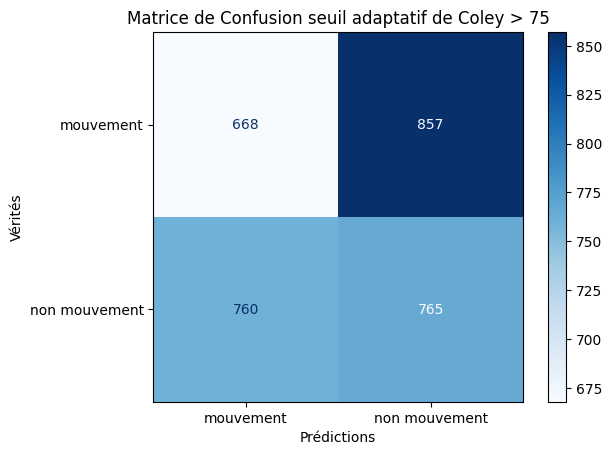

In [ ]:

# Evaluate the model

# F1 score
f1score_mouvement = f1_score(Y_flat, predicted_1Hz_clean_balanced_str, labels = ["non mouvement","mouvement"], pos_label = "mouvement")
f1score_non_mouvement = f1_score(Y_flat, predicted_1Hz_clean_balanced_str, labels = ["non mouvement","mouvement"], pos_label = "non mouvement")
print("F1 score : ", f1score_non_mouvement)
print("F1 score : ", f1score_mouvement)

# Accuracy
accuracy = accuracy_score(Y_flat, predicted_1Hz_clean_balanced_str)
print(f"Accuracy pour seuil adaptatif de Coley : {accuracy:.2f}")
cm_adaptatif = confusion_matrix(Y_flat, predicted_1Hz_clean_balanced_str)

# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_adaptatif, display_labels= ["mouvement", "non mouvement"])
disp.plot(cmap="Blues")
disp.ax_.set_title("Matrice de Confusion seuil adaptatif de Coley > 75")
disp.ax_.set_xlabel("Prédictions")
disp.ax_.set_ylabel("Vérités")
#disp.figure_.show()
plt.show()